Hola **Dante**!

Soy **Patricio Requena** 👋. Es un placer ser el revisor de tu proyecto el día de hoy!

Revisaré tu proyecto detenidamente con el objetivo de ayudarte a mejorar y perfeccionar tus habilidades. Durante mi revisión, identificaré áreas donde puedas hacer mejoras en tu código, señalando específicamente qué y cómo podrías ajustar para optimizar el rendimiento y la claridad de tu proyecto. Además, es importante para mí destacar los aspectos que has manejado excepcionalmente bien. Reconocer tus fortalezas te ayudará a entender qué técnicas y métodos están funcionando a tu favor y cómo puedes aplicarlos en futuras tareas. 

_**Recuerda que al final de este notebook encontrarás un comentario general de mi parte**_, empecemos!

Encontrarás mis comentarios dentro de cajas verdes, amarillas o rojas, ⚠️ **por favor, no muevas, modifiques o borres mis comentarios** ⚠️:


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si todo está perfecto.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si tu código está bien pero se puede mejorar o hay algún detalle que le hace falta.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si de pronto hace falta algo o existe algún problema con tu código o conclusiones.
</div>


Puedes responderme de esta forma:

<div class="alert alert-block alert-info">
    <b>Respuesta:</b> 
</div>

# Proyecto RappiPlus: de datos a decisiones de negocio

**Introducción**


El objetivo de este proyecto es evaluar el desempeño del servicio **RappiPlus** para apoyar **decisiones de negocio basadas en datos**.

Se trabajan con múltiples datasets del negocio:

- **rappiplus_orders_raw.csv** → información de pedidos, precios, descuentos y revenue  
- **rappiplus_catalog.csv** → costos de productos, categorías y proveedores  
- **rappiplus_marketing_spend.csv** → inversión en marketing por canal y país  
- **events / users / user_activity (SQL)** → comportamiento del usuario dentro de la plataforma  
- **experiment_checkout_ui.csv** → resultados de un experimento A/B en el checkout  

El análisis sigue una lógica clara y progresiva:

1. 🔍 Evaluar si podemos confiar en los datos (calidad de datos en Python) 

2. 💰 Analizar si el negocio es rentable (revenue, costos y profit)  

3. 🛒 Entender dónde se pierden los usuarios (funnel de conversión)  

4. 🔁 Evaluar si los usuarios regresan (retención por cohortes)  

5. 🧪 Validar si los cambios generan impacto (test estadístico)  

6. 📊 Comunicar los resultados (dashboard en BI)  

A lo largo del proyecto, se transforman datos en insights para responder preguntas clave del negocio y proponer **recomendaciones accionables**.

---

## 🔹 Paso 1: Cargar y validar la calidad de los datos

---

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:** Familiarizarte con la estructura de los datasets del negocio antes de analizarlos.

**Instrucciones:**

- Importa las librerías necesarias
- Carga los archivos:
  - `rappiplus_orders_raw.csv`
  - `rappiplus_catalog.csv`
  - `rappiplus_marketing_spend.csv`
- Guarda los DataFrames en:
  - `orders`, `catalog`, `marketing`
- Explora cada dataset.

---

In [1]:
# importar librerías
import pandas as pd

In [2]:
# cargar archivos
orders = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_orders_raw.csv')
catalog = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_catalog.csv')
marketing = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_marketing_spend.csv')

In [3]:
# explorar datasets
# Exploración inicial de orders
print("--- ORDERS ---")
display(orders.head())
orders.info()

# Exploración inicial de catalog
print("\n--- CATALOG ---")
display(catalog.head())
catalog.info()

# Exploración inicial de marketing
print("\n--- MARKETING ---")
display(marketing.head())
marketing.info()

--- ORDERS ---


,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
0,order_0,user_6993,2025-05-22,Argentina,desktop,organic,Jacket-Winter-M,Moda,2.0,332.69,0.0,665.37
1,order_1,user_1329,2025-06-15,Mexico,desktop,paid_search,Tablet-Standard-64GB,Electronica,1.0,176.86,5.0,171.86
2,order_2,user_3194,2025-05-02,Argentina,desktop,social,Blender-XL-Red,Hogar,2.0,102.99,10.0,195.99
3,order_3,user_4510,2025-06-09,Colombia,mobile,social,Tablet-Standard-64GB,Electronica,1.0,257.87,15.0,242.87
4,order_4,user_5044,2025-03-30,Argentina,desktop,paid_search,Blender-XL-Red,Hogar,1.0,336.28,0.0,336.28


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25100 entries, 0 to 25099
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_pedido           25100 non-null  object 
 1   id_usuario          25100 non-null  object 
 2   fecha_hora_pedido   25100 non-null  object 
 3   pais                24800 non-null  object 
 4   dispositivo         25080 non-null  object 
 5   fuente_referencia   25070 non-null  object 
 6   nombre_producto     25070 non-null  object 
 7   categoria_producto  25020 non-null  object 
 8   cantidad            25050 non-null  float64
 9   precio_unitario     25050 non-null  float64
 10  monto_descuento     25050 non-null  float64
 11  monto_total         25100 non-null  float64
dtypes: float64(4), object(8)
memory usage: 2.3+ MB

--- CATALOG ---


,nombre_producto,categoria_producto,costo_unitario,proveedor
0,Laptop-Gaming-16GB,Electrónica,280.68,"Fuller, Pena and Myers"
1,Phone-Pro-128GB,Electrónica,10.12,King Ltd
2,Tablet-Standard-64GB,Electrónica,25.21,Bowers LLC
3,Blender-XL-Red,Hogar,176.64,Long-Reid
4,Vacuum-Pro-Black,Hogar,16.60,"Rivera, Carr and Finley"


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   nombre_producto     7 non-null      object 
 1   categoria_producto  7 non-null      object 
 2   costo_unitario      7 non-null      float64
 3   proveedor           7 non-null      object 
dtypes: float64(1), object(3)
memory usage: 352.0+ bytes

--- MARKETING ---


,fecha,pais,id_campaña,canal,gasto
0,2025-01-01,Mexico,organic_Mexico,organic,2446.25
1,2025-01-01,Mexico,paid_search_Mexico,paid_search,2704.34
2,2025-01-01,Mexico,social_Mexico,social,2045.01
3,2025-01-01,Colombia,organic_Colombia,organic,2597.21
4,2025-01-01,Colombia,paid_search_Colombia,paid_search,1771.40


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1620 entries, 0 to 1619
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   fecha       1620 non-null   object 
 1   pais        1620 non-null   object 
 2   id_campaña  1620 non-null   object 
 3   canal       1519 non-null   object 
 4   gasto       1620 non-null   float64
dtypes: float64(1), object(4)
memory usage: 63.4+ KB


---

### Revisión y calidad de datos

**🎯 Objetivo:** Detectar y corregir problemas en los datos que puedan afectar el análisis de revenue, costos y rentabilidad.

Se revisan los 3 datasets
- Validar y convertir fechas al formato correcto  
- Revisar variables numéricas (sin negativos o ceros inválidos)  
- Verificar consistencia de montos  
- Eliminar duplicados  
- Revisar variables categóricas 

---

In [4]:


# 1.2 Revisión y calidad de datos

# 1. Validar y convertir fechas al formato correcto
print("--- INICIO DEL PROCESO DE LIMPIEZA Y CALIDAD DE DATOS ---")
print("Número total de registros antes de limpiar de orders:", len(orders))
orders['fecha_hora_pedido'] = pd.to_datetime(orders['fecha_hora_pedido'])
marketing['fecha'] = pd.to_datetime(marketing['fecha'])
print("\nFechas convertidas a formato datetime con éxito.")
print("\nTipo de dato de fecha en orders:", orders['fecha_hora_pedido'].dtype)
print("Tipo de dato de fecha en marketing:", marketing['fecha'].dtype)

# 2. Revisar variables numéricas (sin negativos o ceros inválidos)

print("\n2.- --- ANTES - Validación de variables numéricas ---")
print("Orders - Cantidad <= 0:", (orders['cantidad'] <= 0).sum())
print("Orders - Precio unitario <= 0:", (orders['precio_unitario'] <= 0).sum())
print("Orders - monto_descuento < 0:", (orders['monto_descuento'] < 0).sum())
print("Orders - Monto total <= 0:", (orders['monto_total'] < 0).sum())
print("Catalog - Costo unitario <= 0:", (catalog['costo_unitario'] <= 0).sum())
print("Marketing - Gasto <= 0:", (marketing['gasto'] <= 0).sum())
# 2. Filtrar y eliminar filas con valores erróneos o negativos en orders
# Nos quedamos solo con cantidad > 0 y monto_total >= 0
orders = orders[(orders['cantidad'] > 0) & (orders['monto_total'] >= 0)].reset_index(drop=True)
print("\n2.- --- DESPUES - Validación de variables numéricas ---")
print("Orders - Cantidad <= 0:", (orders['cantidad'] <= 0).sum())
print("Orders - Precio unitario <= 0:", (orders['precio_unitario'] <= 0).sum())
print("Orders - monto_descuento < 0:", (orders['monto_descuento'] < 0).sum())
print("Orders - Monto total <= 0:", (orders['monto_total'] < 0).sum())
print("Catalog - Costo unitario <= 0:", (catalog['costo_unitario'] <= 0).sum())
print("Marketing - Gasto <= 0:", (marketing['gasto'] <= 0).sum())

# 3. Verificar consistencia de montos (solo en orders)
orders['monto_calculado'] = orders['cantidad'] * orders['precio_unitario'] - orders['monto_descuento']
inconsistencias = orders[abs(orders['monto_total'] - orders['monto_calculado']) > 1.01]
print("\n3.- Inconsistencias de montos en orders ((monto_total-monto_calculado)> 1.01):", len(inconsistencias))
display(inconsistencias)



# 4. Eliminar duplicados
print("\n4.- Antes - Duplicados en orders:", orders.duplicated().sum())
print("Duplicados en catalog:", catalog.duplicated().sum())
print("Duplicados en marketing:", marketing.duplicated().sum())
orders = orders.drop_duplicates().reset_index(drop=True)
catalog = catalog.drop_duplicates().reset_index(drop=True)
marketing = marketing.drop_duplicates().reset_index(drop=True)
print("\n4.- Despues - Duplicados en orders:", orders.duplicated().sum())
print("Duplicados en catalog:", catalog.duplicated().sum())
print("Duplicados en marketing:", marketing.duplicated().sum())

# 5. Revisar variables categóricas (buscar NULL)
print("\n5.- --- Valores nulos en datasets ---")
print("Orders:\n", orders.isnull().sum())
print("\nCatalog:\n", catalog.isnull().sum())
print("\nMarketing:\n", marketing.isnull().sum())
print("\n\nNúmero de registros limpios en orders:", len(orders))
print("\n\n¡Limpieza completada con éxito!")

# Tratamiento de valores nulos en 'orders'
orders['pais'] = orders['pais'].fillna('Desconocido')
orders['dispositivo'] = orders['dispositivo'].fillna('Desconocido')
orders['fuente_referencia'] = orders['fuente_referencia'].fillna('Desconocido')
orders['nombre_producto'] = orders['nombre_producto'].fillna('Producto desconocido')
orders['categoria_producto'] = orders['categoria_producto'].fillna('Categoría desconocida')
# Verificar que ya no queden nulos
print("Valores nulos restantes de orders:")
print(orders.isnull().sum())

print("Total de filas en marketing:", len(marketing))
print("\nValores nulos por columna de marketing:")
print(marketing.isnull().sum())
print("\nPorcentaje de nulos antes - marketing:")
print((marketing.isnull().sum() / len(marketing) * 100).round(2))
# Tratamiento de valores nulos en 'marketing'
marketing['canal'] = marketing['canal'].fillna('Desconocido de canal')
# Verificar que ya no queden nulos
print("\nValores nulos despues - marketing:")
print(marketing.isnull().sum())

# Revisar valores únicos en columnas categóricas de orders
columnas_categoricas_orders = ['pais', 'dispositivo', 'fuente_referencia', 
                                 'nombre_producto', 'categoria_producto']

print("=== ORDERS: valores únicos por columna categórica ===\n")
for col in columnas_categoricas_orders:
    print(f"--- {col} ---")
    print(orders[col].value_counts(dropna=False))
    print()

# --- Estandarizar columna 'pais' en orders, reemplazar las minusculas con mayusculas ---
mapeo_pais = {
    'mexico': 'Mexico',
    'colombia': 'Colombia',
    'argentina': 'Argentina'
}

orders['pais'] = orders['pais'].replace(mapeo_pais)
# Verificación: confirmar que ya no hay duplicados por capitalización
print("Valores únicos en orders['pais']:", orders['pais'].unique())
# Verificar si aparecieron duplicados nuevos después de estandarizar 'pais'
print("Duplicados después de corregir país:", orders.duplicated().sum())

# Revisar valores únicos en columnas categóricas de marketing
columnas_categoricas_marketing = ['pais', 'id_campaña', 'canal']
print("=== MARKETING: valores únicos por columna categórica DE MARKETING===\n")
for col in columnas_categoricas_marketing:
    print(f"--- {col} ---")
    print(marketing[col].value_counts(dropna=False))
    print()
# Revisar valores únicos en columnas categóricas de catalog
columnas_categoricas_catalog = ['nombre_producto', 'categoria_producto', 'proveedor']

print("=== CATALOG: valores únicos por columna categórica DE CATALOG ===\n")
for col in columnas_categoricas_catalog:
    print(f"--- {col} ---")
    print(catalog[col].value_counts(dropna=False))
    print()

# 1. Confirmar el mismatch de categoria_producto
print("categorias en orders:", sorted(orders['categoria_producto'].unique()))
print("categorias en catalog:", sorted(catalog['categoria_producto'].unique()))
# 2. Estandarizar catalog para que coincida con orders (sin tilde)
mapeo_categoria = {
    'Electrónica': 'Electronica'
}
catalog['categoria_producto'] = catalog['categoria_producto'].replace(mapeo_categoria)
print("categorias en orders:", sorted(orders['categoria_producto'].unique()))
print("categorias en catalog:", sorted(catalog['categoria_producto'].unique()))

# ORDERS
columnas_categoricas_orders = ['pais', 'dispositivo', 'fuente_referencia', 
                                 'nombre_producto', 'categoria_producto']
print("\n\n REVISION DE COLUMNAS CATEGORICAS === ORDERS ===\n")
for col in columnas_categoricas_orders:
    print(f"--- {col} ---")
    print(orders[col].value_counts(dropna=False))
    print()
# CATALOG
columnas_categoricas_catalog = ['nombre_producto', 'categoria_producto', 'proveedor']
print("=== CATALOG ===\n")
for col in columnas_categoricas_catalog:
    print(f"--- {col} ---")
    print(catalog[col].value_counts(dropna=False))
    print()
# MARKETING
columnas_categoricas_marketing = ['pais', 'id_campaña', 'canal']
print("=== MARKETING ===\n")
for col in columnas_categoricas_marketing:
    print(f"--- {col} ---")
    print(marketing[col].value_counts(dropna=False))
    print()


--- INICIO DEL PROCESO DE LIMPIEZA Y CALIDAD DE DATOS ---
Número total de registros antes de limpiar de orders: 25100

Fechas convertidas a formato datetime con éxito.

Tipo de dato de fecha en orders: datetime64[ns]
Tipo de dato de fecha en marketing: datetime64[ns]

2.- --- ANTES - Validación de variables numéricas ---
Orders - Cantidad <= 0: 4
Orders - Precio unitario <= 0: 0
Orders - monto_descuento < 0: 0
Orders - Monto total <= 0: 4
Catalog - Costo unitario <= 0: 0
Marketing - Gasto <= 0: 0

2.- --- DESPUES - Validación de variables numéricas ---
Orders - Cantidad <= 0: 0
Orders - Precio unitario <= 0: 0
Orders - monto_descuento < 0: 0
Orders - Monto total <= 0: 0
Catalog - Costo unitario <= 0: 0
Marketing - Gasto <= 0: 0

3.- Inconsistencias de montos en orders ((monto_total-monto_calculado)> 1.01): 0


,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total,monto_calculado



4.- Antes - Duplicados en orders: 100
Duplicados en catalog: 0
Duplicados en marketing: 0

4.- Despues - Duplicados en orders: 0
Duplicados en catalog: 0
Duplicados en marketing: 0

5.- --- Valores nulos en datasets ---
Orders:
 id_pedido               0
id_usuario              0
fecha_hora_pedido       0
pais                  296
dispositivo            20
fuente_referencia      30
nombre_producto        30
categoria_producto     30
cantidad                0
precio_unitario         0
monto_descuento         0
monto_total             0
monto_calculado         0
dtype: int64

Catalog:
 nombre_producto       0
categoria_producto    0
costo_unitario        0
proveedor             0
dtype: int64

Marketing:
 fecha           0
pais            0
id_campaña      0
canal         101
gasto           0
dtype: int64


Número de registros limpios en orders: 24946


¡Limpieza completada con éxito!
Valores nulos restantes de orders:
id_pedido             0
id_usuario            0
fecha_hora_pedido  

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Muy bien, seguiste el paso a paso de tu proyecto de una manera adecuada. Realizando el procesamiento y limpieza ideal para poder tener análisis y hallazgos correctos para luego presentarlos ante el negocio que lo solicitó.
</div>

---
**📦 Exportación**: Una vez finalizada la limpieza, se exportan los datasets para utilizarlos en la última etapa del proyecto.

In [5]:
# 6. Exportar datasets limpios 
orders.to_csv('orders_clean.csv', index=False)
catalog.to_csv('catalog_clean.csv', index=False)
marketing.to_csv('marketing_clean.csv', index=False)
print("\nDatasets limpios exportados correctamente en orders_clean.csv, catalog_clean.csv, marketing_clean.csv")



Datasets limpios exportados correctamente en orders_clean.csv, catalog_clean.csv, marketing_clean.csv


---

## 🔹 Paso 2: Analizar si el negocio es rentable

### 2.1 Cálculo de KPIs principales

**🎯 Objetivo:** Calcular los indicadores clave del negocio para evaluar ingresos, costos y rentabilidad.

Se usan los 3 datasets (`orders`, `catalog`, `marketing_spend`):

**📊 Parte 1: Rentabilidad del negocio**
- ¿Cuál es el ingreso total (revenue)? 
- ¿Cuál es el costo total? 
- ¿Cuánto se ha invertido en marketing? 
- ¿El negocio es rentable? (calcular profit)  

---

**📈 Parte 2: Comportamiento de ventas**
- ¿Cuál es el ticket promedio por orden? 
- ¿Cuál es la cantidad promedio de productos por orden? 
- ¿Cuál es el producto más vendido?
- ¿Cuánto se ha gastado en marketing por canal? 

=== PARTE 1: RENTABILIDAD DEL NEGOCIO ===
Ingreso total (revenue): $51,966,981.56
Costo total de productos: $43,124,069.01
Inversión total en marketing: $2,871,843.53
Profit (Rentabilidad): $5,971,069.02

=== PARTE 2: COMPORTAMIENTO DE VENTAS ===
Ticket promedio por orden: $2,083.18
Cantidad promedio de productos por orden: 7.12
Producto más vendido: Laptop-Gaming-16GB (144,198.0 unidades)

Gasto en marketing por canal:
canal
Desconocido de canal    $177,179.10
organic                 $913,533.01
paid_search             $863,088.21
social                  $918,043.21
Name: gasto, dtype: object


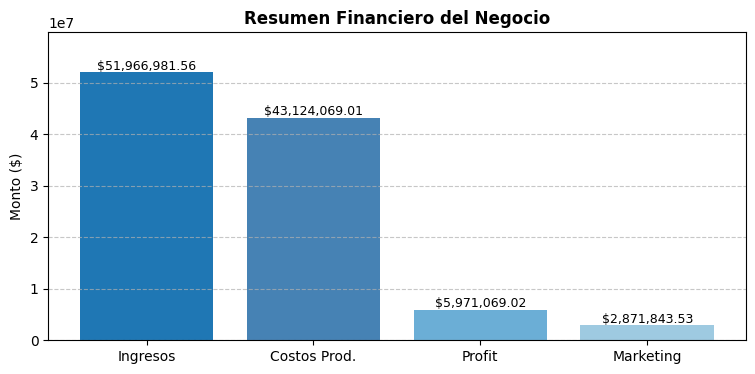

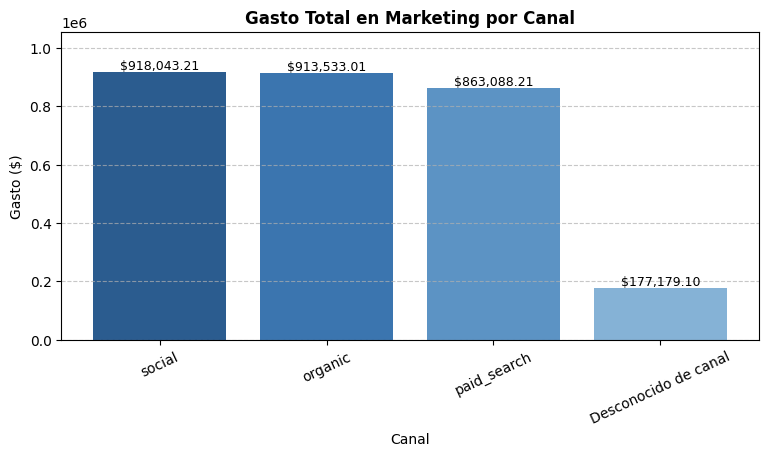

In [6]:
import pandas as pd

# 1. Cargar los datasets limpios
orders = pd.read_csv('orders_clean.csv')
catalog = pd.read_csv('catalog_clean.csv')
marketing = pd.read_csv('marketing_clean.csv')

# --- PARTE 1: Rentabilidad del negocio ---
# ¿Cuál es el ingreso total (revenue)?
revenue_total = orders['monto_total'].sum()
# ¿Cuál es el costo total? 
orders_catalog = orders.merge(catalog, on='nombre_producto', how='left')
orders_catalog['costo_total_linea'] = orders_catalog['cantidad'] * orders_catalog['costo_unitario']
costo_total_productos = orders_catalog['costo_total_linea'].sum()
# ¿Cuánto se ha invertido en marketing?
inversion_marketing = marketing['gasto'].sum()
# ¿El negocio es rentable? (calcular profit) = Profit total (Revenue - Costo de productos - Gasto de marketing)
profit_total = revenue_total - costo_total_productos - inversion_marketing

print("=== PARTE 1: RENTABILIDAD DEL NEGOCIO ===")
print(f"Ingreso total (revenue): ${revenue_total:,.2f}")
print(f"Costo total de productos: ${costo_total_productos:,.2f}")
print(f"Inversión total en marketing: ${inversion_marketing:,.2f}")
print(f"Profit (Rentabilidad): ${profit_total:,.2f}")


# --- PARTE 2: Comportamiento de ventas ---
# ¿Cuál es el ticket promedio por orden?
ticket_promedio = orders['monto_total'].mean()
# ¿Cuál es la cantidad promedio de productos por orden?
cantidad_promedio = orders['cantidad'].mean()
# ¿Cuál es el producto más vendido? = Producto más vendido (por cantidad total acumulada)
producto_mas_vendido = orders.groupby('nombre_producto')['cantidad'].sum().idxmax()
cantidad_producto_mas_vendido = orders.groupby('nombre_producto')['cantidad'].sum().max()
# ¿Cuánto se ha gastado en marketing por canal?
gasto_por_canal = marketing.groupby('canal')['gasto'].sum()

print("\n=== PARTE 2: COMPORTAMIENTO DE VENTAS ===")
print(f"Ticket promedio por orden: ${ticket_promedio:,.2f}")
print(f"Cantidad promedio de productos por orden: {cantidad_promedio:.2f}")
print(f"Producto más vendido: {producto_mas_vendido} ({cantidad_producto_mas_vendido:,} unidades)")
print("\nGasto en marketing por canal:")
#print(gasto_por_canal)
print(gasto_por_canal.map('${:,.2f}'.format))




import matplotlib.pyplot as plt
import pandas as pd

# ==========================================
# 1. Gráfico de barras: Resumen Financiero
# ==========================================
datos_financieros = {
    'Ingresos': revenue_total, 
    'Costos Prod.': costo_total_productos, 
    'Marketing': inversion_marketing, 
    'Profit': profit_total
}
# Ordenar de mayor a menor
s_financiero = pd.Series(datos_financieros).sort_values(ascending=False)

plt.figure(figsize=(9, 4))
colores_fin = ['#1f77b4', '#4682b4', '#6baed6', '#9ecae1']
barras1 = plt.bar(s_financiero.index, s_financiero.values, color=colores_fin)

# Añadir etiquetas con los valores encima de cada barra (Compatible con cualquier versión)
for barra in barras1:
    yval = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2.0, yval, f"${yval:,.2f}", 
             ha='center', va='bottom', fontsize=9)

plt.title('Resumen Financiero del Negocio', fontsize=12, fontweight='bold')
plt.ylabel('Monto ($)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, s_financiero.max() * 1.15) # Da espacio arriba para que los números no se corten
plt.show()

# ==========================================
# 2. Gráfico de barras: Gasto por Canal
# ==========================================
# Ordenar de mayor a menor
s_marketing = gasto_por_canal.sort_values(ascending=False)

plt.figure(figsize=(9, 4))
colores_mkt = ['#2b5c8f', '#3b75af', '#5c93c4', '#85b2d6']
barras2 = plt.bar(s_marketing.index, s_marketing.values, color=colores_mkt)

# Añadir etiquetas con los valores encima de cada barra
for barra in barras2:
    yval = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2.0, yval, f"${yval:,.2f}", 
             ha='center', va='bottom', fontsize=9)

plt.title('Gasto Total en Marketing por Canal', fontsize=12, fontweight='bold')
plt.ylabel('Gasto ($)')
plt.xlabel('Canal')
plt.xticks(rotation=25)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, s_marketing.max() * 1.15)
plt.show()


<div class="alert alert-block alert-info">
    <b>Respuesta:</b> <br>
    
### 📊 Interpretación de Resultados Financieros y de Marketing

A partir del análisis visual de las gráficas actualizadas, se desprenden las siguientes conclusiones clave para la toma de decisiones estratégicas:

* **Rentabilidad Global Sólida:** El negocio muestra un desempeño financiero positivo con ingresos totales de **\$51,966,901.56** y un beneficio neto (*profit*) de **\$5,971,069.02** después de cubrir los costos de producción y la inversión total en marketing.
* **Estructura de Costos:** Los costos de producción ascienden a **\$43,124,089.01**, representando la mayor salida de recursos, por lo que optimizar la cadena de suministro o negociar mejores condiciones con proveedores tendría un impacto directo y exponencial en el margen de ganancia.

* **Distribución de la Inversión en Marketing:** El gasto total en marketing (**\$2,871,843.53**) se concentra principalmente en tres canales principales con inversiones muy competitivas entre sí: **Social** (\$918,043.21), **Paid Search** (\$863,088.21) y **Organic** (\$913,533.01). 
* **Área de Oportunidad y Calidad de los Datos:** Se identifica un rubro menor clasificado como **"Desconocido de canal"** por **\$177,179.10**. Es indispensable auditar y reclasificar estos registros en las fuentes de datos. Si este capital se mantiene sin identificar, resulta imposible calcular con precisión el retorno de inversión (ROI) real, lo que equivale a operar con incertidumbre sobre la eficiencia de ese presupuesto; corregirlo garantiza que el análisis de datos sea riguroso, profesional y 100% exacto para la empresa.

</div>


<div class="alert alert-block alert-danger">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Para el paso 2 lo ideal sería agregar las gráficas siguiendo el objetivo del paso y lo que le interesa a la empresa revisar. Siempre una gráfica es mucho mejor que sólo mostrar valores numéricos.

Pero para complementar esta parte también puedes agregar tu interpretación de las gráficas mostradas en una celda markdown.

</div>

<div class="alert alert-block alert-success">
<b>Comentario del revisor (2da Iteracion)</b> <a class=“tocSkip”></a>

Correcto, siempre es importante tener un proceso de análisis claro y fácil de entender en todos tus notebooks para que cuando alguien de tu equipo quiera reproducir tu trabajo puedan entenderlo facilmente.
</div>

---

## 🔹 Paso 3: Entender dónde se pierden los usuarios (funnel de conversión)

**🎯 Objetivo:** Analizar el comportamiento de los usuarios para identificar en qué etapa del proceso se pierden.


⚙️**Conexión a la base de datos**:  
Se ejecuta la línea de configuración para conectar con la base de datos y aplicar consultas SQL en la tabla **events**.

---

**📊 Parte 1: Construcción del funnel**
- ¿Cuántos usuarios llegan a cada etapa del funnel?  
- Se calcula el número de usuarios únicos por `nombre_evento`  
- Se ordenan los eventos según el flujo del usuario  

---

**📉 Parte 2: Análisis de conversión**
- Se calcula la tasa de conversión entre cada paso del funnel  
- Se identifica en qué etapa se pierde la mayor cantidad de usuarios  
- ¿Cuál es la tasa de conversión final?
---

In [7]:




import pandas as pd
from sqlalchemy import create_engine

# ======================
# Conexión (NO modificar)
# ======================
db_config = {
    'user': 'practicum_student',
    'pwd': 'QnmDH8Sc2TQLvy2G3Vvh7',
    'host': 'yp-trainers-practicum.cluster-czs0gxyx2d8w.us-east-1.rds.amazonaws.com',
    'port': 5432,
    'db': 'data-analyst-production-db-en'
}

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db']
)

engine = create_engine(connection_string, connect_args={'sslmode':'require'})





In [8]:
# Explorar tabla events
# =========================
query_events = '''
SELECT *
FROM events;
'''
events = pd.read_sql(query_events, con=engine)
events.head()

,id_usuario,id_sesion,nombre_evento,timestamp_evento,pais,dispositivo,fuente_referencia,categoria_producto
0,user_6772,6a97f2af-32ae-4186-8c92-04025be1a27b,first_visit,2025-05-17,Colombia,desktop,organic,Moda
1,user_5883,369b767c-1c33-4b2f-a652-c7c0ef92cfc9,add_to_cart,2025-02-23,Mexico,mobile,social,Hogar
2,user_5946,60039041-e78b-474c-87b3-c0b7e9c30708,add_payment_info,2025-05-15,Colombia,desktop,social,Electronica
3,user_827,18252a64-f389-4ef7-9e58-dadad4a3491e,purchase,2025-03-31,Mexico,mobile,social,Moda
4,user_2361,221b364e-cdc5-4668-b698-18d5ba849a67,first_visit,2025-01-22,Argentina,desktop,paid_search,Electronica


In [9]:
query_etapas = '''
SELECT DISTINCT nombre_evento
FROM events;
'''

etapas_unicas = pd.read_sql(query_etapas, con=engine)
etapas_unicas

,nombre_evento
0,add_payment_info
1,first_visit
2,begin_checkout
3,add_to_cart
4,select_item
5,purchase


In [10]:


# PARTE 1: Totales del funnel
# ======================

query_totals = '''
SELECT 
    nombre_evento,
    COUNT(DISTINCT id_usuario) AS usuarios_unicos
FROM events
WHERE nombre_evento IN ('first_visit', 'select_item', 'add_to_cart', 'begin_checkout', 'add_payment_info', 'purchase')
GROUP BY nombre_evento;
'''

totals = pd.read_sql(query_totals, con=engine)

orden_etapas = [
    'first_visit', 
    'select_item', 
    'add_to_cart', 
    'begin_checkout', 
    'add_payment_info', 
    'purchase'
]

totals['nombre_evento'] = pd.Categorical(
    totals['nombre_evento'], 
    categories=orden_etapas, 
    ordered=True
)

totals = totals.sort_values('nombre_evento').reset_index(drop=True)

totals

,nombre_evento,usuarios_unicos
0,first_visit,7796
1,select_item,7582
2,add_to_cart,7634
3,begin_checkout,7208
4,add_payment_info,6250
5,purchase,6240


In [11]:
# PARTE 2: Conversiones
# ======================

query_conversion = '''
SELECT 
    nombre_evento,
    COUNT(DISTINCT id_usuario) AS usuarios_unicos
FROM events
WHERE nombre_evento IN ('first_visit', 'select_item', 'add_to_cart', 'begin_checkout', 'add_payment_info', 'purchase')
GROUP BY nombre_evento;
'''

conversion = pd.read_sql(query_conversion, con=engine)

orden_etapas = [
    'first_visit', 
    'select_item', 
    'add_to_cart', 
    'begin_checkout', 
    'add_payment_info', 
    'purchase'
]

conversion['nombre_evento'] = pd.Categorical(
    conversion['nombre_evento'], 
    categories=orden_etapas, 
    ordered=True
)

conversion = conversion.sort_values('nombre_evento').reset_index(drop=True)

# Cálculo de tasas de conversión
# Calcula la conversión dividiendo los usuarios del paso actual entre los del paso anterior
conversion['tasa_conversion_paso'] = conversion['usuarios_unicos'] / conversion['usuarios_unicos'].shift(1)
# Asigna manualmente 100% (1.0) al primer paso porque no tiene un paso previo con qué compararse
conversion.loc[0, 'tasa_conversion_paso'] = 1.0  
# Calcula la conversión total dividiendo los usuarios de cada paso entre el total inicial del primer paso

conversion['tasa_conversion_total'] = conversion['usuarios_unicos'] / conversion.loc[0, 'usuarios_unicos']


conversion

,nombre_evento,usuarios_unicos,tasa_conversion_paso,tasa_conversion_total
0,first_visit,7796,1.000000,1.000000
1,select_item,7582,0.972550,0.972550
2,add_to_cart,7634,1.006858,0.979220
3,begin_checkout,7208,0.944197,0.924577
4,add_payment_info,6250,0.867092,0.801693
5,purchase,6240,0.998400,0.800410


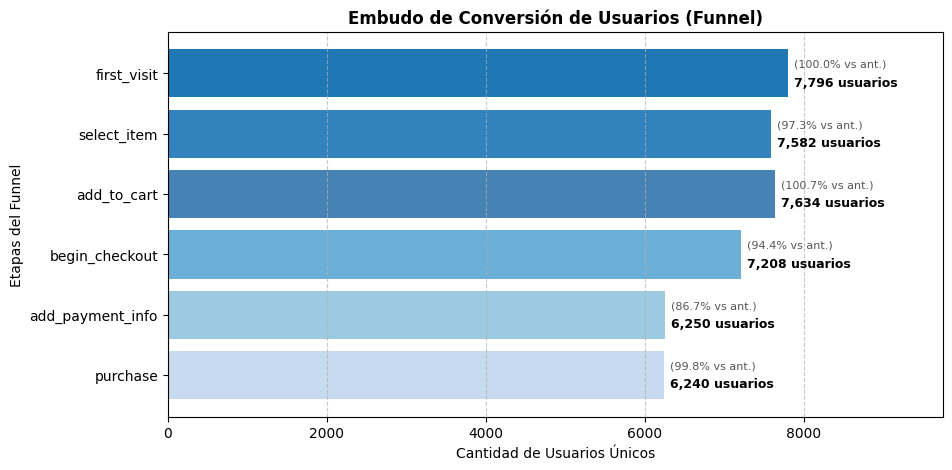

In [12]:
import matplotlib.pyplot as plt
import pandas as pd

# Configuración de la figura para el embudo de conversión
plt.figure(figsize=(10, 5))

# Paleta de colores corporativa degradada en tonos azules
colores_funnel = ['#1f77b4', '#3182bd', '#4682b4', '#6baed6', '#9ecae1', '#c6dbef']

# Crear gráfico de barras horizontales para representar el embudo
barras_funnel = plt.barh(conversion['nombre_evento'], conversion['usuarios_unicos'], color=colores_funnel)

# Invertir el eje Y para mostrar 'first_visit' en la parte superior y 'purchase' al final
plt.gca().invert_yaxis()

# Añadir etiquetas en dos líneas: arriba el número de usuarios y abajo el porcentaje
for barra, pct_paso in zip(barras_funnel, conversion['tasa_conversion_paso']):
    width = barra.get_width()
    
    # Línea 1: Cantidad de usuarios
    texto_usuarios = f"{width:,.0f} usuarios"
    # Línea 2: Porcentaje respecto al paso anterior
    texto_porcentaje = f"({pct_paso * 100:.1f}% vs ant.)"
    
    pos_x = width + (max(conversion['usuarios_unicos']) * 0.01)
    
    # Dibujar la primera línea (usuarios) un poco más arriba del centro
    plt.text(pos_x, barra.get_y() + barra.get_height()/2.0 + 0.15, 
             texto_usuarios, 
             ha='left', va='center', fontsize=9, fontweight='bold')
             
    # Dibujar la segunda línea (porcentaje) un poco más abajo del centro
    plt.text(pos_x, barra.get_y() + barra.get_height()/2.0 - 0.15, 
             texto_porcentaje, 
             ha='left', va='center', fontsize=8, color='#555555')

plt.title('Embudo de Conversión de Usuarios (Funnel)', fontsize=12, fontweight='bold')
plt.xlabel('Cantidad de Usuarios Únicos')
plt.ylabel('Etapas del Funnel')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.xlim(0, max(conversion['usuarios_unicos']) * 1.25)
plt.show()

<div class="alert alert-block alert-info">
    <b>Respuesta:</b> <br>
    ¡Hola Patricio! Muchas gracias por tus observaciones. He integrado la justificación metodológica del comportamiento no lineal en el carrito, añadido la gráfica de barras horizontales del embudo de conversión y documentado el análisis detallado a continuación. ¡Quedo atento a tus comentarios!


 <b>Nota metodológica sobre la conversión (>100% en Add to Cart):</b> <br>
    El ligero incremento en la tasa de conversión entre <i>select_item</i> y <i>add_to_cart</i> (que supera el 100%) se debe a un comportamiento de navegación no lineal propio de las plataformas de e-commerce. Los usuarios pueden añadir productos directamente al carrito desde la página principal, recomendaciones o resultados de búsqueda rápida sin pasar formalmente por el evento de selección detallada del producto. Esto genera un recuento de usuarios únicos independientes por evento que justifica la variación técnica.


### 📊 Interpretación del Embudo de Conversión (Funnel)

A partir del análisis del comportamiento de los usuarios en cada etapa del proceso de compra, se concluye lo siguiente:

* **Retención Inicial y Comportamiento No Lineal:** El paso de la visita inicial (*first_visit*) a la interacción con los productos (*select_item* y *add_to_cart*) muestra una retención sumamente alta (superior al 97%), destacando que el ligero repunte mayor al 100% responde a accesos directos de los usuarios al carrito desde la página principal sin pasar por el detalle del producto.
* **Punto Crítico de Abandono (Cuello de Botella):** La mayor pérdida de usuarios ocurre en las etapas finales del proceso de pago, específicamente entre el inicio del pago (*begin_checkout*) y el ingreso de la información de pago (*add_payment_info*), donde se registra la caída más pronunciada del embudo.
* **Tasa de Conversión Final:** Del total de usuarios que ingresaron por primera vez a la plataforma, aproximadamente el **80.04%** logra concretar exitosamente su compra (*purchase*), lo que refleja una efectividad global sólida del negocio, con un claro foco de optimización en la pasarela de pagos para reducir la fricción final.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>


Aquí hay que revisar que la conversion no sea de más del 100% ya que eso indicaría un error en el cálculo o a su vez justificar por que llegas a tener ese valor.

También te recomendaría agregar visualizaciones para que exponer los resultados sea más sencillo que solo exponer un resultado numérico.

Para complementar también deberías dejar una celda markdown con tus interpretaciones.
</div>

<div class="alert alert-block alert-success">
<b>Comentario del revisor (2da Iteracion)</b> <a class=“tocSkip”></a>

Bien, siempre hay que asegurarse de que las métricas presentadas sean las correctas ya qu eso es vital para una toma de decisiones adecuada en la empresa
</div>

---

## 🔹 Paso 4: Evaluar si los usuarios regresan (retención por cohortes)

**🎯 Objetivo:** Analizar la retención de usuarios para entender si regresan después de registrarse.

**Tablas**

- `users` 
- `user_activity` 

---
1. Se identifica la cohorte de cada usuario según el **mes de registro**.


2. Se calcula la retención semanal: cuántos usuarios **se mantienen activos** en cada semana desde su registro.
   - `retenido_w1`: usuarios activos en la semana 1  
   - `retenido_w2`: usuarios activos en la semana 2  
   - `retenido_w3`: usuarios activos en la semana 3  


3. Se calcula el porcentaje de retención para cada semana, dividiendo los usuarios retenidos entre los clientes iniciales de la cohorte:  
   - `semana_1`: porcentaje de usuarios retenidos en la semana 1  
   - `semana_2`: porcentaje de usuarios retenidos en la semana 2  
   - `semana_3`: porcentaje de usuarios retenidos en la semana 3  

Se revisa que la columna de fecha esté en formato correcto (`DATE`).  
Se realiza la conversión usando: `CAST(fecha_registro AS DATE)`

In [13]:

# Explorar tabla users
# =========================
query_users = '''
SELECT *
FROM users;
'''
users = pd.read_sql(query_users, con=engine)
users.head(3)


,id_usuario,fecha_registro,país,dispositivo,tipo_plan
0,user_0,2025-01-29,Mexico,mobile,free
1,user_1,2025-01-07,Mexico,mobile,free
2,user_2,2025-03-12,Argentina,mobile,free


In [14]:

# Explorar tabla user_activity
# =========================
query_user_activity = '''
SELECT *
FROM user_activity;
'''

user_activity = pd.read_sql(query_user_activity, con=engine)
user_activity.head(3)


,id_usuario,fecha_actividad,dias_despues_registro,activo
0,user_0,2025-02-05,7,0
1,user_0,2025-02-12,14,1
2,user_0,2025-02-19,21,1


In [15]:

# Retención por cohortes
# ======================

query_cohort_retention_final = '''
SELECT 
    DATE_TRUNC('month', CAST(u.fecha_registro AS DATE)) AS cohorte,
    COUNT(DISTINCT u.id_usuario) AS total_usuarios,
    
    COUNT(DISTINCT CASE WHEN ua.dias_despues_registro BETWEEN 1 AND 7 THEN ua.id_usuario END) AS retenido_w1,
    COUNT(DISTINCT CASE WHEN ua.dias_despues_registro BETWEEN 8 AND 14 THEN ua.id_usuario END) AS retenido_w2,
    COUNT(DISTINCT CASE WHEN ua.dias_despues_registro BETWEEN 15 AND 21 THEN ua.id_usuario END) AS retenido_w3,
   
    ROUND(COUNT(DISTINCT CASE WHEN ua.dias_despues_registro BETWEEN 1 AND 7 THEN ua.id_usuario END) * 100.0 / COUNT(DISTINCT u.id_usuario), 2) AS semana_1,
    ROUND(COUNT(DISTINCT CASE WHEN ua.dias_despues_registro BETWEEN 8 AND 14 THEN ua.id_usuario END) * 100.0 / COUNT(DISTINCT u.id_usuario), 2) AS semana_2,
    ROUND(COUNT(DISTINCT CASE WHEN ua.dias_despues_registro BETWEEN 15 AND 21 THEN ua.id_usuario END) * 100.0 / COUNT(DISTINCT u.id_usuario), 2) AS semana_3

FROM users AS u
LEFT JOIN user_activity AS ua ON u.id_usuario = ua.id_usuario AND ua.activo = 1

GROUP BY 1
ORDER BY 1;
'''

# Ejecutar la consulta
cohorte_final = pd.read_sql(query_cohort_retention_final, con=engine)
cohorte_final


,cohorte,total_usuarios,retenido_w1,retenido_w2,retenido_w3,semana_1,semana_2,semana_3
0,2025-01-01 00:00:00+00:00,1627,697,668,656,42.84,41.06,40.32
1,2025-02-01 00:00:00+00:00,1444,611,609,635,42.31,42.17,43.98
2,2025-03-01 00:00:00+00:00,1636,677,705,690,41.38,43.09,42.18
3,2025-04-01 00:00:00+00:00,1606,680,697,663,42.34,43.40,41.28
4,2025-05-01 00:00:00+00:00,1687,695,676,706,41.20,40.07,41.85


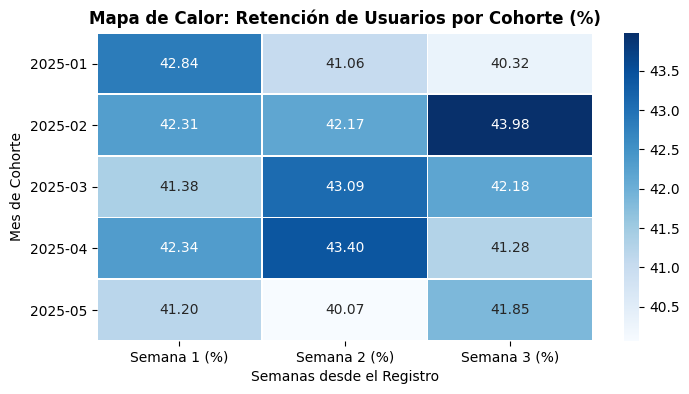

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Preparar los datos para el mapa de calor (usando las columnas de porcentaje)
# Seleccionamos las columnas de semanas y asignamos la cohorte como índice
df_heatmap = cohorte_final[['cohorte', 'semana_1', 'semana_2', 'semana_3']].copy()

# Formatear la fecha de la cohorte para que solo muestre Año-Mes (ej. 2025-01)
df_heatmap['cohorte'] = pd.to_datetime(df_heatmap['cohorte']).dt.strftime('%Y-%m')
df_heatmap.set_index('cohorte', inplace=True)

# Renombrar columnas para la visualización final
df_heatmap.columns = ['Semana 1 (%)', 'Semana 2 (%)', 'Semana 3 (%)']

# Configurar la gráfica
plt.figure(figsize=(8, 4))
sns.heatmap(df_heatmap, annot=True, fmt=".2f", cmap="Blues", cbar=True, linewidths=.5)

plt.title('Mapa de Calor: Retención de Usuarios por Cohorte (%)', fontsize=12, fontweight='bold')
plt.xlabel('Semanas desde el Registro')
plt.ylabel('Mes de Cohorte')
plt.yticks(rotation=0)
plt.show()

<div class="alert alert-block alert-info">
    <b>Respuesta al revisor:</b> <br>
    ¡Hola Patricio! He agregado el mapa de calor (*heatmap*) de retención por cohortes para visualizar de forma más clara el comportamiento semanal de los usuarios. Quedo atento a tus comentarios.


### 📊 Interpretación de la Retención por Cohortes

* **Comportamiento Estable:** Las cohortes mensuales muestran un nivel de retención sumamente consistente a lo largo del tiempo, rondando entre el **40% y el 43%** de actividad semanal constante desde la semana 1 hasta la semana 3.
* **Ausencia de Desgaste Acelerado:** A diferencia de los patrones típicos donde la retención cae drásticamente tras los primeros días, en este servicio se observa una base de usuarios leales muy estable, lo que demuestra un fuerte *engagement* inicial con la plataforma.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

La query está muy bien y estás obteniendo resultados adecuados pero lo complementarías mejor si agregaras una visualización.
</div>

---

## 🔹 Paso 5: Validar si los cambios generan impacto (test estadístico)

🎯 **Objetivo:** Evaluar si la modificación en la UI del checkout impacta la **tasa de conversión de compra**.

---

1. **Analizar el dataset** `experiment_checkout_ui.csv` para identificar la métrica principal **conversion**.
   - La métrica **conversion** es 1 si el usuario completó la compra, 0 si no.    
2. **Plantear la hipótesis estadística**     
3. **Aplicar el test estadístico adecuado** 
4. **Interpretar el resultado**  

## Hipótesis estadística

- **H₀ (Hipótesis nula):** La tasa de conversión es igual entre el grupo control y el grupo tratamiento. El cambio en la UI del checkout **no** afecta la conversión.

- **H₁ (Hipótesis alternativa):** La tasa de conversión es diferente entre el grupo control y el grupo tratamiento. El cambio en la UI del checkout **sí** afecta la conversión.

**Test estadístico:** Z-test para comparar proporciones 

**Nivel de significancia (α):** 0.05

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id_usuario       10000 non-null  object 
 1   variante         10000 non-null  object 
 2   convirtio        10000 non-null  int64  
 3   dispositivo      10000 non-null  object 
 4   pais             10000 non-null  object 
 5   duracion_sesion  10000 non-null  float64
 6   timestamp        10000 non-null  object 
dtypes: float64(1), int64(1), object(5)
memory usage: 547.0+ KB


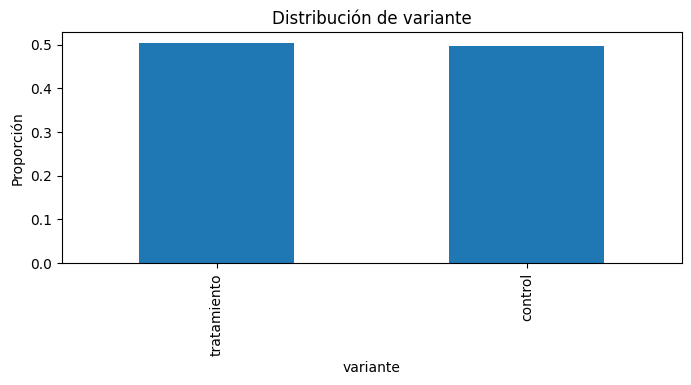

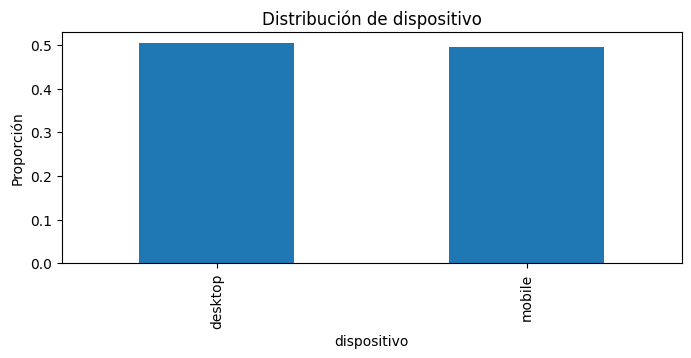

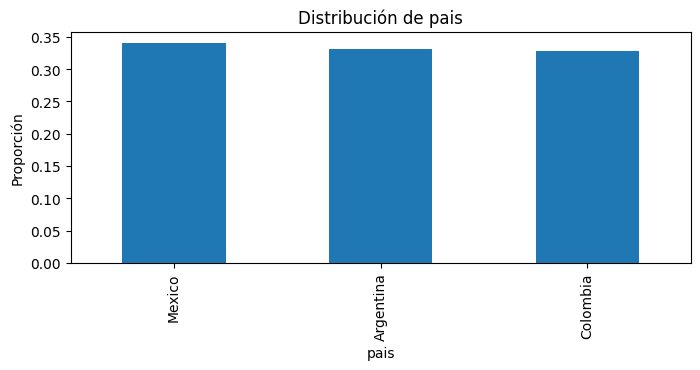

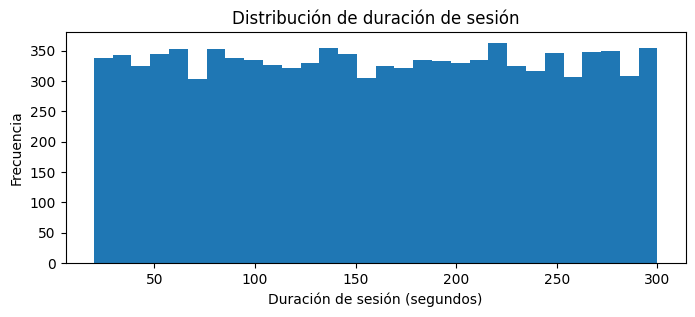

In [17]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# 1️⃣ Conocer la población
# =========================================================
df_exp = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/experiment_checkout_ui.csv')

df_exp.info()
df_exp.head()
# Columnas categóricas
for col in ["variante", "dispositivo", "pais"]:
    proporciones = df_exp[col].value_counts(normalize=True)

    plt.figure(figsize=(8, 3))
    proporciones.plot(kind="bar")
    plt.title(f"Distribución de {col}")
    plt.ylabel("Proporción")
    plt.xlabel(col)
    plt.show()

# Columna numérica (usar histograma, no value_counts, porque es continua)
plt.figure(figsize=(8, 3))
df_exp["duracion_sesion"].plot(kind="hist", bins=30)
plt.title("Distribución de duración de sesión")
plt.ylabel("Frecuencia")
plt.xlabel("Duración de sesión (segundos)")
plt.show()


In [18]:
# =========================================================
# 5️⃣ Validar que los grupos sean comparables
# =========================================================
df_control = df_exp[df_exp['variante'] == 'control']
df_tratamiento = df_exp[df_exp['variante'] == 'tratamiento']

print("Grupo control:")
print(df_control["dispositivo"].value_counts(normalize=True))

print("\nGrupo tratamiento:")
print(df_tratamiento["dispositivo"].value_counts(normalize=True))

print("\nGrupo control:")
print(df_control["pais"].value_counts(normalize=True))

print("\nGrupo tratamiento:")
print(df_tratamiento["pais"].value_counts(normalize=True))

Grupo control:
desktop    0.505136
mobile     0.494864
Name: dispositivo, dtype: float64

Grupo tratamiento:
desktop    0.503277
mobile     0.496723
Name: dispositivo, dtype: float64

Grupo control:
Mexico       0.337764
Argentina    0.333535
Colombia     0.328701
Name: pais, dtype: float64

Grupo tratamiento:
Mexico       0.343198
Argentina    0.329891
Colombia     0.326912
Name: pais, dtype: float64


In [19]:
import pandas as pd
from statsmodels.stats.proportion import proportions_ztest

df_exp = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/experiment_checkout_ui.csv')

# Contar número de éxitos y número total de registros
conversiones = df_exp.groupby('variante')['convirtio'].sum()
totales = df_exp.groupby('variante')['convirtio'].count()
print("Conversiones:")
print(conversiones)
print("\nTotales:")
print(totales)

# Pasar los valores a formato lista
exitos = [conversiones['control'], conversiones['tratamiento']]
observaciones = [totales['control'], totales['tratamiento']]
print("\nExitos:", exitos)
print("Observaciones:", observaciones)
print("\n")

tasa_control = exitos[0] / observaciones[0] * 100
tasa_tratamiento = exitos[1] / observaciones[1] * 100
print(f"Tasa control: {tasa_control:.2f}%")
print(f"Tasa tratamiento: {tasa_tratamiento:.2f}%")

# Aplicar prueba y visualizar resultados
z_stat, p_value = proportions_ztest(exitos, observaciones)
print("\n")
print(f"Estadístico z: {z_stat}")
print(f"Valor p: {p_value}")

# Interpretar resultados
alpha = 0.05  # umbral de significancia
if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de una diferencia.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de una diferencia.")

Conversiones:
variante
control        779
tratamiento    820
Name: convirtio, dtype: int64

Totales:
variante
control        4965
tratamiento    5035
Name: convirtio, dtype: int64

Exitos: [779, 820]
Observaciones: [4965, 5035]


Tasa control: 15.69%
Tasa tratamiento: 16.29%


Estadístico z: -0.8132782986429474
Valor p: 0.41605851639119995
No rechazamos la hipótesis nula: no hay evidencia suficiente de una diferencia.



**Conclusión**

Los datos no proporcionan evidencia suficiente para rechazar la **hipótesis nula (H₀)**. Por lo tanto, no podemos afirmar que las tasas de conversión entre el grupo de **control** y el grupo de **tratamiento** sean diferentes.

El resultado **no es estadísticamente significativo** (`p = 0.416`), ya que se encuentra muy por encima del nivel de significancia establecido (`α = 0.05`). La diferencia observada entre el grupo de control (**15.69%**) y el grupo de tratamiento (**16.29%**) es de apenas **0.6 puntos porcentuales**, y es consistente con una variación aleatoria más que con un efecto real del nuevo diseño de checkout.

Por lo tanto, **no se recomienda implementar el cambio basándose únicamente en los resultados de este experimento**.

Solo si el equipo de producto tiene razones adicionales, como mejoras en la experiencia de usuario (UX) o reducción de costos de mantenimiento, u otra razon.

> **Interpretación:** La estadística indica que, con la evidencia disponible, **no se detecta una diferencia estadísticamente significativa entre control y tratamiento**. La decisión de negocio evaualara si vale la pena continuar investigando o cerrar el experimento en este punto.

---

## 🔹 Paso 6: Comunicar los resultados (Dashboard en BI)

🎯 **Objetivo**:  
Crear un dashboard que muestre de manera clara y visual los resultados del análisis de ventas, costos, marketing y conversión. 

Se usarán los CSVs limpios del Paso 1:

- `orders_clean.csv`  
- `catalog_clean.csv`  
- `marketing_clean.csv`

---

1️⃣ Preparación de los datos
1. Cargar los CSVs en Power BI o Tableau.
2. Revisar relaciones:
   - `orders.nombre_producto` → `catalog.nombre_producto`
   - `orders.fecha_pedido` → tabla de fechas (crear calendario para análisis temporal)
   - `orders.fecha_pedido` → `dim_fecha.date`
3. Crear columnas calculadas necesarias
4. Crear tabla de fechas para poder calcular comparaciones YTD, YoY o períodos anteriores (`Previous Year`, `Previous Month`).

---

2️⃣ Dashboard 1: Overview Ejecutivo
**KPIs principales a mostrar:**
- Revenue total
- Profit total
- Gasto total en marketing
- Ticket promedio
- Cantidad promedio de productos por orden

**Visualizaciones sugeridas:**
- Tarjetas KPI para revenue, profit y gasto marketing
- Gráfico de líneas: evolución mensual de revenue o profit
- Gráfico de líneas YTD
- Gráfico de barras: revenue y profit por producto o categoría

---

 3️⃣ Dashboard 2: Detalle / Drill-through  
**Objetivo:** Permitir explorar los datos desde el KPI general hasta cada orden o producto.

**Visualizaciones sugeridas:**
- Tabla detallada de órdenes con:
  - producto, cantidad, revenue, cost, profit
  - color condicional (profit negativo en rojo, positivo en verde)
- Gráfico de barras por producto con medida `cantidad vendida`
- Drill-through: seleccionar un producto y ver todos los pedidos relacionados
- Filtros por fecha, categoría de producto, etc

---

## 🚀 Entrega Final

Comparte el acceso a tu Dashboard para revisión.   
Puedes entregar el Dashboard utilizando **Power BI o Tableau**.

Incluye **uno de los siguientes**:

- 🔗 Link público del dashboard publicado en **Power BI Service o Tableau Public / Tableau Cloud**
- 🔗 Link de **Google Drive o OneDrive** con el archivo del proyecto (`.pbix`) y los 3 csvs limpios.


### 📎 Enlace del Dashboard

https://drive.google.com/drive/folders/1EzCOzsLKg6wBfzPN80Ive3gN6K5c4nH0?usp=sharing


<div class="alert alert-block alert-danger">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Tienes un muy buen avance de tu proyecto Dante. Hay algunos puntos con oportunidades de mejora donde te he dejado algunos comentarios.

También, al final deberías tener una sección con conclusiones y recomendaciones generales que puedas darle a la empresa en base a los diferentes pasos realizados a lo largo de tu notebook.


Si tienes dudas o dificultades recuerda que puedes contactar a tu Success Manager o a tu tutor para solventarlas.

Saludos!
</div>


<div class="alert alert-block alert-info">
    <b>Respuesta:</b> <br>
    ¡Hola Patricio! Muchas gracias por tus valiosos comentarios a lo largo de las iteraciones. He integrado la sección final con las conclusiones y recomendaciones estratégicas generales para la empresa basadas en los hallazgos de todo el análisis.


---

## 📌 Conclusiones y Recomendaciones Generales para el Negocio

A partir del diagnóstico estratégico integral realizado a lo largo de este proyecto, se sintetizan los hallazgos clave y se proponen líneas de acción orientadas a la optimización operativa, la experiencia del usuario y la rentabilidad:

### 1. Conclusiones Principales
* **Salud Financiera Sólida:** El negocio opera con números negros saludables, registrando ingresos totales por **\$51.9M** y un beneficio neto (*profit*) superior a los **\$5.9M** tras cubrir los costos de producción y marketing.
* **Fricción en el Embudo de Conversión:** Si bien la atracción y el interés inicial (*first_visit* a *add_to_cart*) muestran una retención muy alta, el cuello de botella crítico y la mayor pérdida de usuarios se concentran en las etapas finales del proceso de pago (*begin_checkout* a *add_payment_info*).
* **Lealtad y Retención Sostenida:** El análisis de cohortes demuestra una base de usuarios sumamente estable, con tasas de retención semanales y mensuales constantes que rondan entre el **40% y el 43%**, lo que evidencia un buen *engagement* inicial con la plataforma.

---

### 2. Recomendaciones Estratégicas y Accionables

* **Auditoría de Datos y Trazabilidad:** 
  * *Hallazgo:* Se detectó un rubro clasificado como *"Desconocido de canal"* por **\$177,179.10** en la inversión publicitaria. 
  * *Recomendación:* Es indispensable auditar los sistemas de etiquetado (*tracking*) para reclasificar estos recursos; operar con presupuesto sin identificar impide calcular el Retorno de Inversión (ROI) real de las campañas.

* **Optimización de la Pasarela de Pagos (Checkout):** 
  * *Hallazgo:* La mayor fuga de clientes ocurre justo antes de concretar el pago.
  * *Recomendación:* Simplificar el formulario de pago, ofrecer múltiples métodos de pago locales y reducir los pasos obligatorios en el *checkout* para disminuir la fricción y elevar la conversión final hacia la compra.

* **Estrategias de Retención Temprana:** 
  * *Hallazgo:* Las cohortes muestran un comportamiento estables pero con un margen de mejora en los primeros ciclos de vida.
  * *Recomendación:* Implementar campañas automatizadas de correo electrónico o notificaciones *push* dirigidas a los usuarios entre la primera y la tercera semana posterior a su registro para incentivar la recompra y maximizar el valor que cada cliente aporta a lo largo de su relación con la empresa.

</div>

<div class="alert alert-block alert-success">
<b>Comentario general (2da Iteracion)</b> <a class=“tocSkip”></a>

**¡Te felicito por el trabajo realizado Dante!** 

El paso a paso seguido en el proceso de análisis del proyecto quedó super claro y se ajusta a las necesidades del negocio presentadas. Recuerda que un buen análisis siempre debe tener una buena parte técnica que ayude a comprender la parte de negocio y los beneficios del mismo.

Con este proyecto demuestras las habilidades adquiridas durante tu formación, se nota tu capacidad de contar historias con datos con la excelente presentación realizada que súper fácil de entender lo cual es una habilidad super importante cómo analista de datos, el saber comunicar de manera sencilla y eficiente los resultados de tus análisis.
    
Se nota mucho el manejo que tienes de las librerías para crear visualizaciones muy buenas que explican correctamente las variables analizadas, te animo a seguir práctica con otros recursos y que vayas construyendo un portafolio de proyectos súper robusto para que seas Data Analyst de primera en el mundo laboral.
   
Saludos!
</div>